# Exercise 4.A Introduction to Machine Learning

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
# Exercise 4.A Introduction to Linear Regression

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [15]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}

df = pd.DataFrame(data)

X = df[['hours_studied']]
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [16]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [17]:
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [18]:
r_squared = model.score(X_test, y_test)

print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R² score shows how much of the variation in exam score is explained by hours studied. A higher R² means the model fits the data better.

c:\Users\dagmawimulugeta\Documents\Data-analytics-2026\pre-week-7\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


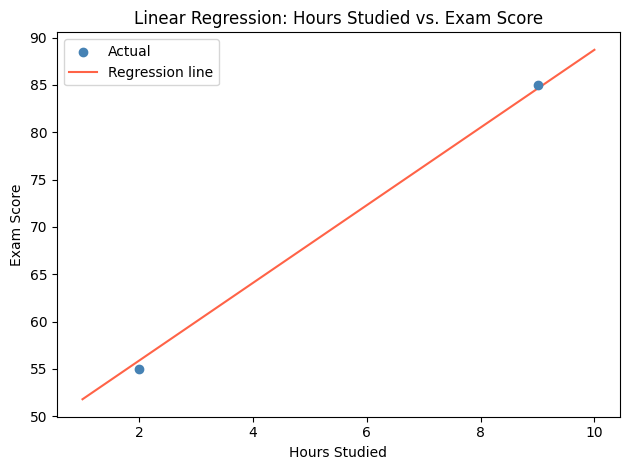

In [19]:
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_range)

plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points appear close to the regression line, which shows that the model is finding a clear relationship between hours studied and exam score.

## Lab 2
### Building your own model

In [25]:
ad_data = {
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
    'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100, 23800]
}

df_ads = pd.DataFrame(ad_data)

df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [26]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print(X2.shape)
print(y2.shape)

(20, 1)
(20,)


In [27]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [28]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

print("Model trained successfully.")

Model trained successfully.


In [29]:
print(f'\nSlope (coefficient): {model2.coef_[0]:.2f}')
print(f'Intercept: {model2.intercept_:.2f}')


Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [32]:
y2_pred = model2.predict(X2_test)

comparison = pd.DataFrame({
    'Actual Revenue': y2_test.values,
    'Predicted Revenue': y2_pred.round(2)
})

comparison

,Actual Revenue,Predicted Revenue
0,4200,4603.85
1,21500,21229.03
2,19400,19273.13
3,5100,5581.80


In [33]:
r_squared2 = model2.score(X2_test, y2_test)

print(f'R² score: {r_squared2:.3f}')
print(f'This means about {r_squared2 * 100:.1f}% of the variation in revenue is explained by ad spend.')

R² score: 0.998
This means about 99.8% of the variation in revenue is explained by ad spend.


The model appears to be a good fit if the R² score is close to 1. This means monthly ad spend explains a large percentage of the variation in monthly revenue.

### Visualizing the results

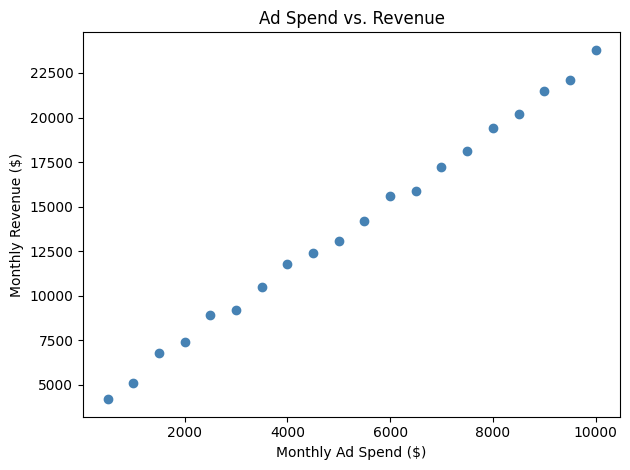

In [36]:
plt.scatter(X2, y2, color='steelblue')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.tight_layout()
plt.show()

c:\Users\dagmawimulugeta\Documents\Data-analytics-2026\pre-week-7\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


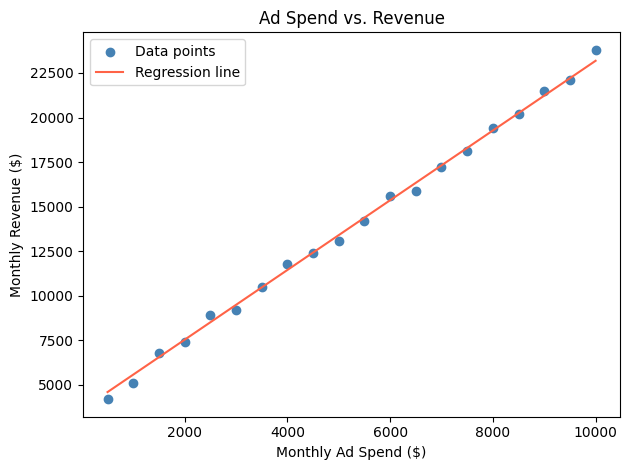

In [37]:
plt.scatter(X2, y2, color='steelblue', label='Data points')

x_range2 = np.linspace(
    X2['monthly_ad_spend'].min(),
    X2['monthly_ad_spend'].max(),
    100
).reshape(-1, 1)

y_line2 = model2.predict(x_range2)

plt.plot(x_range2, y_line2, color='tomato', label='Regression line')
plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.tight_layout()
plt.show()

The regression line appears to fit the data well visually because the points follow an upward trend close to the line. This matches the R² score because both show a strong relationship between ad spend and revenue.